# A Deeper Analysis and Understanding of the Government Time Series Data

Feature meanings and Importance

Fire and Burning and Drought Metrics

> **burn** — Wildfire Probability Index *(% Probability)*  
Represents the estimated probability of wildfire at a location. High values typically reflect hotter, drier conditions and reduced fuel moisture.

> **energy_ERC** — Energy Release Component *(BTU/ft²)*  
Measures the potential heat energy per unit area that would be released if a fire ignited. Increases during extended dry periods and is a strong indicator of drought stress and low fuel moisture.

> **dfm100** and **dfm1000** — Dead Fuel Moisture *(% moisture content)*  
dfm100 represents moisture in 1–3 inch dead fuels and responds to weather changes over ~4 days.  
dfm1000 represents moisture in 3–8 inch dead fuels and responds over ~45 days.  
These metrics track short‑term and long‑term drying of vegetation.

Temperature and Humidity Metrics

> **maxT** and **minT** — Maximum and Minimum Temperature *(Kelvin)*  
Daily high and low air temperatures at the site. Higher temperatures accelerate evaporation and increase drying stress.

> **maxRelH** and **minRelH** — Maximum and Minimum Relative Humidity *(% Humidity)*  
Daily high and low relative humidity. High RH indicates moisture recovery; low RH indicates active drying of soils and vegetation.

> **SpecificH** — Specific Humidity *(kg water vapor / kg air)*  
Absolute moisture content of the air, independent of temperature. Useful for tracking true atmospheric moisture availability.

> **vaporDeficit** — Vapor Pressure Deficit (VPD) *(kPa)*  
Difference between the air’s moisture capacity at saturation and its actual moisture content. High VPD means the air is actively pulling moisture from soil, vegetation, and surface water.

Precipitation and Evaporation Metrics

> **precipitation** — Total Precipitation *(mm)*  
Amount of rainfall reaching the ground. Directly influences soil moisture, streamflow, and drought recovery.

> **alfalfa** and **grass** — Reference Evapotranspiration *(mm/day)*  
Estimated water loss from a well‑watered alfalfa or grass field due to sunlight, wind, and temperature. High ET values indicate strong atmospheric demand and potential soil‑moisture loss.

Atmospheric Metrics

> **sunshine** — Solar Radiation *(W/m²)*  
Amount of incoming solar energy at the surface. Drives heating of shallow streams and increases evaporation rates.

> **windDirection** — Wind Direction *(degrees from north)*  
Indicates the direction the wind is coming from.

> **windSpeed** — Wind Speed *(m/s)*  
Higher wind speeds accelerate evaporation, increase drying of fuels, and intensify VPD effects.

Palmer Drought Indices

> **palmer_p** — Palmer Hydrological Drought Index *(unitless)*  
Tracks long‑term water availability, including groundwater, reservoir storage, and streamflow. Slow to change and indicates persistent, large‑scale drought conditions.

> **palmer_z** — Palmer Moisture Anomaly Index *(unitless)*  
Captures short‑term (month‑to‑month) agricultural drought relative to normal moisture levels. Responds quickly to precipitation deficits or surpluses.

Importing the libraries, and loading the datasets I will be using for the notebook.

In [2]:

# Importing the plotting and DataFrame libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split

# Importing Models
import xgboost as xgb

# Importing Metrics
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Selecting seaborn color palette
color_palette = sns.color_palette()

# Evaluating the Data

In [3]:
# Load the dataset
gov_10dts = pd.read_csv('../data/gov_envData10dts_2025.csv')

# Display information about the dataset
gov_10dts.info()
print(f"\nShape: {gov_10dts.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876 entries, 0 to 875
Columns: 829 entries, Segment_10Day to site_46.palmer_z
dtypes: float64(828), int64(1)
memory usage: 5.5 MB

Shape: (876, 829)


In [4]:
# Display the first five rows of the dataset
gov_10dts.head()

,Segment_10Day,site_1.burn,site_1.dfm1000hr,site_1.dfm100hr,site_1.energy_ERC,site_1.maxT,site_1.maxRelH,site_1.vaporDeficit,site_1.minT,site_1.minRelH,...,site_46.minRelH,site_46.specificH,site_46.precipitation,site_46.alfalfa,site_46.grass,site_46.sunshine,site_46.windDirection,site_46.windSpeed,site_46.palmer_p,site_46.palmer_z
0,0,23.4,20.15,21.12,18.1,278.05,100.00,0.167,265.17,61.66,...,54.77,0.002996,0.00,1.59,1.01,83.93,203.6,4.17,9.0,5.0
1,1,25.5,19.36,17.29,24.5,279.21,89.81,0.308,265.85,33.84,...,32.60,0.002320,0.00,2.36,1.47,95.22,185.4,3.89,4.5,4.0
2,2,25.3,18.09,15.66,28.3,274.64,86.27,0.220,263.58,36.57,...,36.14,0.001879,0.33,1.55,1.01,82.95,154.3,3.16,4.0,4.0
3,3,30.9,17.65,16.91,29.1,280.54,90.99,0.354,266.27,37.03,...,34.46,0.002358,0.00,2.75,1.79,113.53,253.2,4.07,3.0,3.5
4,4,16.2,17.47,17.54,23.8,277.45,94.03,0.243,266.65,44.17,...,43.36,0.002566,0.77,2.13,1.42,101.44,143.3,4.26,3.0,4.5


In [5]:
# Display the last five rows of the dataset
gov_10dts.tail()

,Segment_10Day,site_1.burn,site_1.dfm1000hr,site_1.dfm100hr,site_1.energy_ERC,site_1.maxT,site_1.maxRelH,site_1.vaporDeficit,site_1.minT,site_1.minRelH,...,site_46.minRelH,site_46.specificH,site_46.precipitation,site_46.alfalfa,site_46.grass,site_46.sunshine,site_46.windDirection,site_46.windSpeed,site_46.palmer_p,site_46.palmer_z
871,871,36.4,15.04,14.91,38.5,291.07,84.62,0.726,274.06,27.76,...,29.55,0.004603,0.00,3.77,2.40,107.41,202.5,3.82,2.0,4.0
872,872,26.0,15.66,16.13,31.3,281.41,82.38,0.363,270.61,42.70,...,45.55,0.003484,2.28,2.17,1.39,84.47,161.6,4.46,2.0,4.0
873,873,28.0,17.19,18.76,27.0,278.56,96.37,0.231,267.22,47.87,...,47.64,0.002855,0.03,1.51,1.00,93.11,260.5,3.59,2.0,4.5
874,874,24.4,17.29,16.53,28.0,282.57,87.21,0.388,270.39,41.59,...,40.77,0.003252,0.83,2.37,1.46,83.50,189.0,3.73,2.0,4.0
875,875,18.1,18.15,19.38,20.5,281.64,92.43,0.181,271.12,61.89,...,61.34,0.004657,3.38,1.37,0.91,70.14,221.1,4.18,2.0,4.5


In [6]:
# Selecting columns related to site_1 for manual inspection

site_1_cols = [col for col in gov_10dts.columns if 'site_1.' in col]
site_1_df = gov_10dts[site_1_cols]
site_1_df.columns = [col.replace('site_1.', '') for col in site_1_df.columns]
print(site_1_df.columns)


Index(['burn', 'dfm1000hr', 'dfm100hr', 'energy_ERC', 'maxT', 'maxRelH',
       'vaporDeficit', 'minT', 'minRelH', 'specificH', 'precipitation',
       'alfalfa', 'grass', 'sunshine', 'windDirection', 'windSpeed',
       'palmer_p', 'palmer_z'],
      dtype='object')


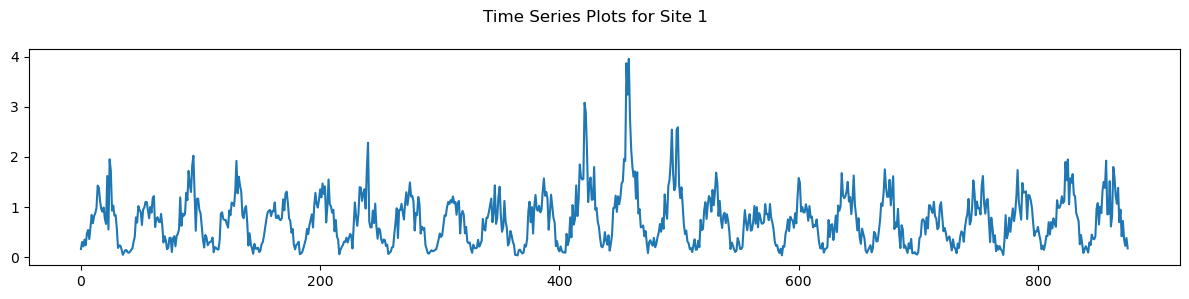

In [7]:
site_1_df['vaporDeficit'].plot(subplots=True, 
               figsize=(12, 3), 
               color=color_palette[0], 
               title='Time Series Plots for Site 1', 
               legend=False)
plt.tight_layout()
plt.show()

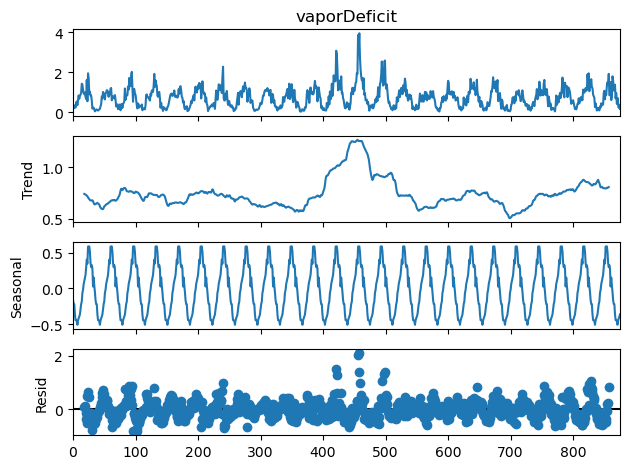

In [8]:
# Decomposing the time series to analyze its components

decomp = seasonal_decompose(site_1_df['vaporDeficit'], model='additive', period=36) # 36 periods corresponds to 10 day intervals in a year (365/10 ≈ 36.5)

decomp.plot()
plt.tight_layout()
plt.show()

- This decomposition shows the original **vaporDeficit** time series along with its three extracted components:  
  **Trend** (long‑term movement), **Seasonal** (recurring annual oscillation), and **Residual** (short‑term irregular fluctuations that are not explained by trend or seasonality).
- These components are additive, meaning:  
  **Trend + Seasonal + Residual = Original Series**.  
  Removing the residual component produces a smoother, more interpretable signal that can be more suitable for modeling or long‑term analysis.
- The seasonal component clearly captures the repeating sinusoidal pattern driven by annual temperature and humidity cycles, while the trend component highlights slower structural changes over the 24‑year period.

**Notes**

- The vapor deficit trend shows a noticeable elevation between approximately **period 350 and 550**, peaking around **period 450**, indicating a sustained interval of unusually high atmospheric drying potential.  
- This may correspond to a multi‑year drought or a cluster of extreme heat events.

In [9]:
# Running the Augmented Dickey-Fuller test to check for stationary
# and a p-value of less than 0.05 to confirm stationary

trend = decomp.trend.dropna()   # Using only the trend component for ADF test

adf_result = adfuller(trend)
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

ADF Statistic: -2.8220114362739235
p-value: 0.05519772894416745


- The **p-value (0.055)** is slightly above the **0.05** significance threshold, so we fail to reject the null hypothesis that the series contains a **unit root**.
- This suggests that the long‑term component of **vaporDeficit** is **borderline non‑stationary** — it behaves almost stationary, but still shows enough drift that it cannot be treated as fully mean‑reverting.
- In practice, this means the series may exhibit **weak long‑term trends** or slow structural shifts that accumulate over time.
- For modeling, this indicates that **differencing**, **trend removal**, or **seasonal adjustment** may be necessary before applying methods that assume stationary.
- Because the p‑value is close to the threshold, it is useful to also inspect the **trend slope**, **seasonal strength**, and **residual behavior** to determine whether the non-stationary is meaningful or simply reflects long‑term climate variability.
stationary

The trend is stable.
Trend Slope: 0.0


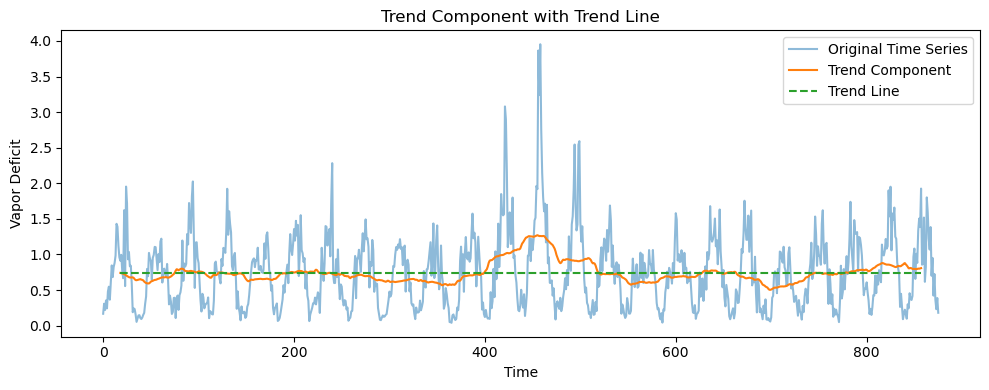

In [11]:
# Calculating the slope of the trend component to determine if it's increasing or decreasing

trend_slope = np.polyfit(range(len(trend)), trend, 1)[0]

trend_slope = np.round(trend_slope, 2)  # Rounding the slope for better readability

if trend_slope > 0:
    print("The trend is increasing.")
elif trend_slope < 0:
    print("The trend is decreasing.")
else:
    print("The trend is stable.")
    
print(f"Trend Slope: {trend_slope}")

plt.figure(figsize=(10, 4))

plt.plot(site_1_df['vaporDeficit'], label='Original Time Series', color=color_palette[0], alpha=0.5)
plt.plot(trend.index, trend.values, label='Trend Component', color=color_palette[1])
plt.plot(trend.index, trend_slope * np.arange(len(trend)) + trend.values[0], label='Trend Line', color=color_palette[2], linestyle='--')


plt.title('Trend Component with Trend Line')
plt.xlabel('Time')
plt.ylabel('Vapor Deficit')
plt.legend()
plt.tight_layout()



Checking to see if any of any of the features of any of the sites have a global trend

In [ ]:
# Calculating the slope of the trend component to determine if it's increasing or decreasing

for site in range(1, 47):  # Assuming there are 46 sites
    site_cols = [col for col in gov_10dts.columns if f'site_{site}.' in col]
    site_df = gov_10dts[site_cols]
    site_df.columns = [col.replace(f'site_{site}.', '') for col in site_df.columns]
    
    site_df = site_df.drop(['windDirection', 'maxRelH'], axis=1)
    
    for col in site_df.columns:
        decomp = seasonal_decompose(site_df[col], model='additive', period=36)
        trend = decomp.trend.dropna()
        
        if len(trend) > 1:  # Ensure there's enough data to calculate a slope
            trend_slope = np.polyfit(range(len(trend)), trend, 1)[0]
            trend_slope = abs(np.round(trend_slope, 2))
            
            if trend_slope > 0.009:
                print(f"Site {site}, Column '{col}': The trend is increasing. Slope: {trend_slope}")
                
                plt.figure(figsize=(10, 4))

                plt.plot(site_df[col], label='Original Time Series', color=color_palette[0], alpha=0.5)
                plt.plot(trend.index, trend.values, label='Trend Component', color=color_palette[1])
                plt.plot(trend.index, trend_slope * np.arange(len(trend)) + trend.values[0], label='Trend Line', color=color_palette[2], linestyle='--')


                plt.title(f'Site_{site} {col}')
                plt.xlabel('Time')
                plt.ylabel(col)
                plt.legend()
                plt.tight_layout()
            

checking to see how closely the sites respective cols line up and if any in particular are farther off.

In [66]:
feature_names = sorted({col.split('.', 1)[1] for col in gov_10dts.columns.drop('Segment_10Day')})
feature_names = [f for f in feature_names if f != "windDirection"]  # drop circular variable

# Prepare output matrix
distance_matrix = pd.DataFrame(index=range(1, 47), columns=feature_names, dtype=float)

for col in feature_names:

    # Collect trend series for all sites for this feature
    site_trends = {}

    for site in range(1, 47):
        feature_col = f"site_{site}.{col}"
        if feature_col not in gov_10dts.columns:
            continue

        ts = gov_10dts[feature_col].dropna()

        try:
            decomp = seasonal_decompose(ts, model="additive", period=36)
            trend = decomp.trend.dropna()
            site_trends[site] = trend
        except:
            continue

    # Align all trends to the same index
    aligned = pd.concat(site_trends, axis=1).dropna()

    # Compute the "average trend" across all sites
    mean_trend = aligned.mean(axis=1)

    # Compute distance of each site from the mean trend
    for site in aligned.columns:
        diff = (aligned[site] - mean_trend).abs().mean()
        distance_matrix.loc[site, col] = diff


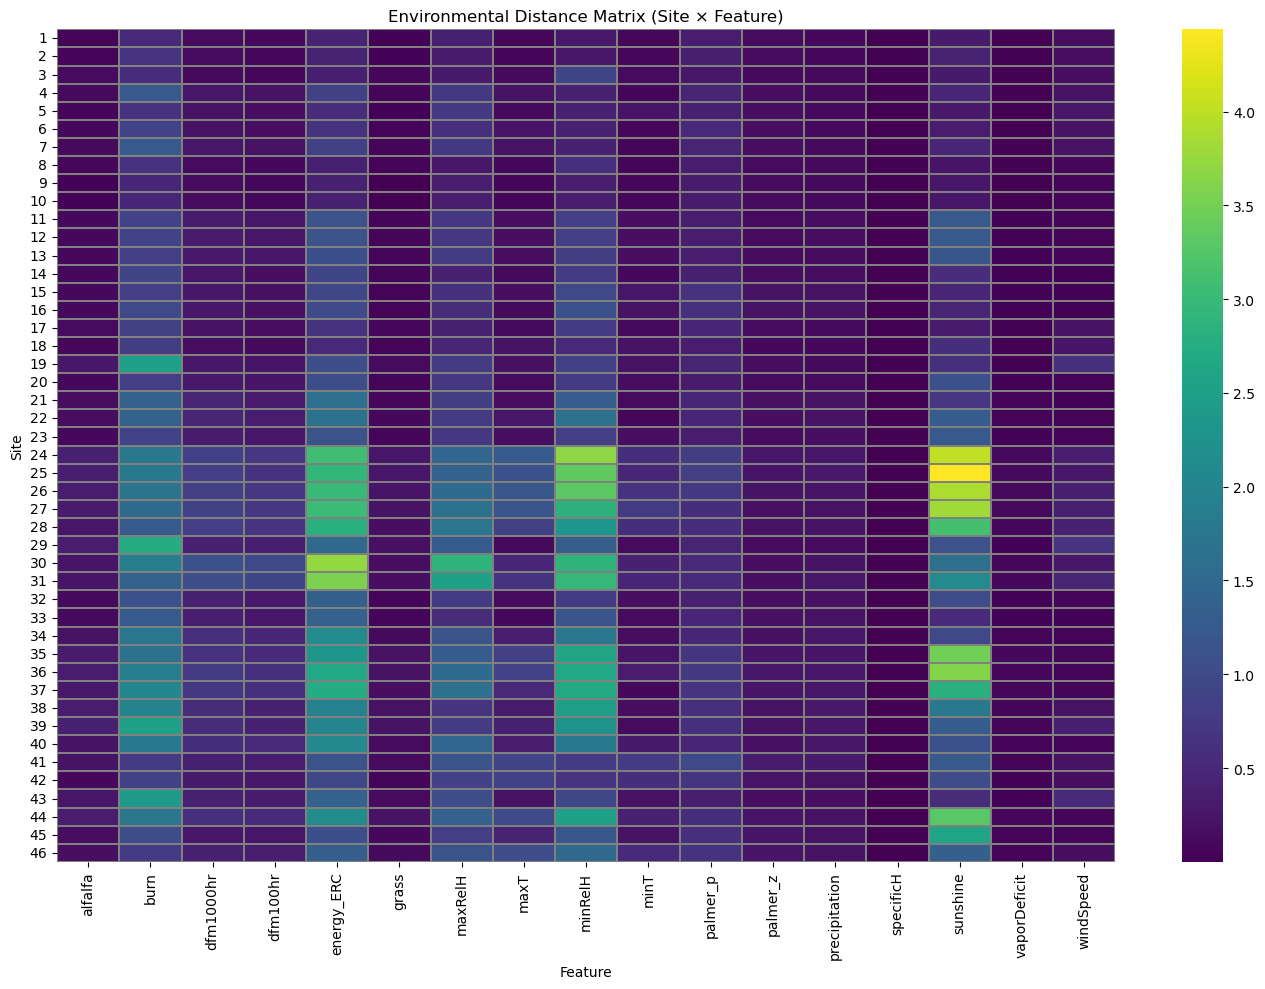

In [69]:
plt.figure(figsize=(14, 10))
sns.heatmap(distance_matrix, cmap="viridis", linewidths=0.3, linecolor='gray')
plt.title("Environmental Distance Matrix (Site × Feature)")
plt.xlabel("Feature")
plt.ylabel("Site")
plt.tight_layout()
plt.show()